<a href="https://colab.research.google.com/github/ArhamBhansali-ab/LandSIght/blob/main/Main/LandSight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Pre-reqs

In [ ]:
!pip install xarray netCDF4 h5netcdf scipy

In [ ]:
!pip install --upgrade google-api-python-client google-auth-httplib2 google-auth-oauthlib

In [ ]:
!pip install rioxarray

In [ ]:
!pip install cftime

In [ ]:
!pip install siphon ipywidgets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [ ]:
import os

# Change directory to your desired folder in Google Drive
os.chdir('/content/drive/MyDrive/Landslide_Detection')

# Verify if the directory was changed successfully
print(os.getcwd())


/content/drive/MyDrive/Landslide_Detection


In [ ]:
## Define file location
path = '/content/drive/MyDrive/Landslide_Detection/'
filename = 'prate.sfc.mon.mean.nc'
filepath = path + filename
print(filepath)
print(os.getcwd())
print(os.path.exists(filepath))


/content/drive/MyDrive/Landslide_Detection/prate.sfc.mon.mean.nc
/content/drive/MyDrive/Landslide_Detection
True


In [ ]:
## Open dataset using xarray package
precip = xr.open_dataset(filepath)
precip

<xarray.Dataset> Size: 40MB
Dimensions:    (lat: 94, lon: 192, time: 548, nbnds: 2)
Coordinates:
  * lat        (lat) float32 376B 88.54 86.65 84.75 ... -84.75 -86.65 -88.54
  * lon        (lon) float32 768B 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time       (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-08-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 9kB ...
    prate      (time, lat, lon) float32 40MB ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [ ]:
## Select the 'prate' data variable from the dataset
## Click on the "Attributes" dropdown below to see more info on the precipitation (prate) variable
precip['prate']

<xarray.DataArray 'prate' (time: 548, lat: 94, lon: 192)> Size: 40MB
[9890304 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 376B 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
  * lon      (lon) float32 768B 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-08-01
Attributes: (12/14)
    long_name:      Monthly Mean of Precipitation Rate at Surface
    units:          Kg/m^2/s
    precision:      7
    GRIB_id:        59
    GRIB_name:      PRATE
    var_desc:       Precipitation Rate
    ...             ...
    statistic:      Mean
    parent_stat:    Individual Obs
    standard_name:  precipitation_rate
    cell_methods:   time: mean (of each 6-hourly interval) mean (monthly of 6...
    valid_range:    [0.       0.006553]
    actual_range:   [0.         0.00116897]

In [ ]:
## Change the units (optional)
## Precipitation SI unit is kg/m2/s, a unit that is hard to interpret. Instead if you multiply by 86400, units are millimeters--way better.
precip['prate'] = precip['prate']*86400

In [ ]:
## See what the time coordinate values look like for the array. Here they span Jan 1979 to Aug 2024
dates = precip['prate'].coords['time'].values
dates

array(['1979-01-01T00:00:00.000000000', '1979-02-01T00:00:00.000000000',
       '1979-03-01T00:00:00.000000000', '1979-04-01T00:00:00.000000000',
       '1979-05-01T00:00:00.000000000', '1979-06-01T00:00:00.000000000',
       '1979-07-01T00:00:00.000000000', '1979-08-01T00:00:00.000000000',
       '1979-09-01T00:00:00.000000000', '1979-10-01T00:00:00.000000000',
       '1979-11-01T00:00:00.000000000', '1979-12-01T00:00:00.000000000',
       '1980-01-01T00:00:00.000000000', '1980-02-01T00:00:00.000000000',
       '1980-03-01T00:00:00.000000000', '1980-04-01T00:00:00.000000000',
       '1980-05-01T00:00:00.000000000', '1980-06-01T00:00:00.000000000',
       '1980-07-01T00:00:00.000000000', '1980-08-01T00:00:00.000000000',
       '1980-09-01T00:00:00.000000000', '1980-10-01T00:00:00.000000000',
       '1980-11-01T00:00:00.000000000', '1980-12-01T00:00:00.000000000',
       '1981-01-01T00:00:00.000000000', '1981-02-01T00:00:00.000000000',
       '1981-03-01T00:00:00.000000000', '1981-04-01

In [ ]:
## Clean up the lat/lon coordinates
## Convert 0 to 360 longitude to -180 to 180
precip = precip.assign_coords(lon = (((precip.lon + 180) % 360) - 180))

## Sort lat and lon coordinates in increasing order
precip = precip.sortby(precip.lon)
precip = precip.sortby(precip.lat)


In [ ]:
## Note how the lat/lon coordinates have changed slightly now
precip['prate']

<xarray.DataArray 'prate' (time: 548, lat: 94, lon: 192)> Size: 79MB
array([[[0.01726002, 0.01726002, 0.01726002, ..., 0.01726002,
         0.01726002, 0.01726002],
        [0.15550107, 0.16415119, 0.1727812 , ..., 0.12959093,
         0.13822094, 0.14687106],
        [0.05182028, 0.04319027, 0.03454015, ..., 0.1123108 ,
         0.09503067, 0.07775053],
        ...,
        [0.42335317, 0.43198317, 0.43198317, ..., 0.43198317,
         0.42335317, 0.42335317],
        [0.35423264, 0.35423264, 0.35423264, ..., 0.36286265,
         0.35423264, 0.35423264],
        [0.24190173, 0.25055185, 0.25918186, ..., 0.22462159,
         0.23327172, 0.24190173]],

       [[0.03454015, 0.03454015, 0.03454015, ..., 0.03454015,
         0.03454015, 0.03454015],
        [0.1209408 , 0.1209408 , 0.1209408 , ..., 0.1209408 ,
         0.1209408 , 0.1209408 ],
        [0.47519356, 0.46654344, 0.4492633 , ..., 0.4492633 ,
         0.46654344, 0.47519356],
...
        [0.66144767, 0.62939613, 0.57010066, ..., 0.76213164,
         0.73377286, 0.69928254],
        [0.97590192, 0.97374198, 0.95715878, ..., 1.0238401 ,
         1.00823231, 0.99116128],
        [0.848671  , 0.8420517 , 0.83968258, ..., 0.85159741,
         0.84894964, 0.84671993]],

       [[0.10395872, 0.10535226, 0.1064671 , ..., 0.10110193,
         0.10214711, 0.10291355],
        [0.17948903, 0.18673546, 0.19363355, ..., 0.15545031,
         0.16388128, 0.17196387],
        [0.21572129, 0.20067097, 0.18443614, ..., 0.24289549,
         0.23753032, 0.22791484],
        ...,
        [1.02697537, 1.02746336, 1.04230475, ..., 1.05192007,
         1.04934193, 1.03526717],
        [0.6950322 , 0.73537551, 0.77913297, ..., 0.61566971,
         0.62103486, 0.66172655],
        [1.02983224, 1.04927239, 1.05226842, ..., 1.05958456,
         1.0559613 , 1.04460385]]])
Coordinates:
  * lat      (lat) float32 376B -88.54 -86.65 -84.75 ... 84.75 86.65 88.54
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-08-01
  * lon      (lon) float32 768B -180.0 -178.1 -176.2 ... 174.4 176.2 178.1

In [ ]:
## Sample a time (Feb 2024) and location
## On this date at that lat/lon location, 5.87mm of rain fell
precip['prate'].sel(time = '2024-02').sel(lat = 32.874622, lon = -60.277069, method = 'nearest').values

array([5.86551649])

Text(0, 0.5, 'Precipitation [mm]')

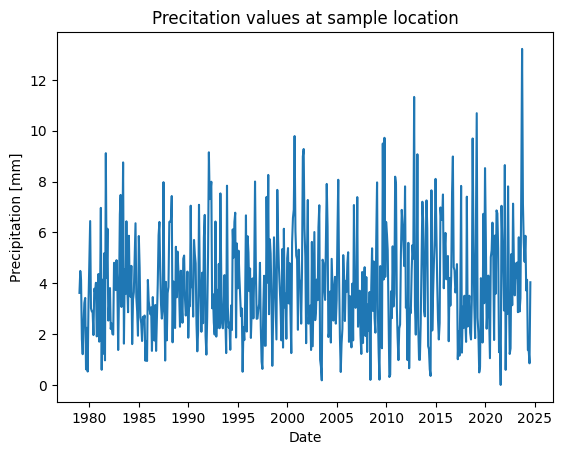

In [ ]:
## Now sample all the values across the time dimension for that same lat/lon location
sample_vals = precip['prate'].sel(lat = 32.874622, lon = -60.277069, method = 'nearest').values
plt.plot(dates, sample_vals)
plt.title('Precitation values at sample location')
plt.xlabel('Date')
plt.ylabel('Precipitation [mm]')

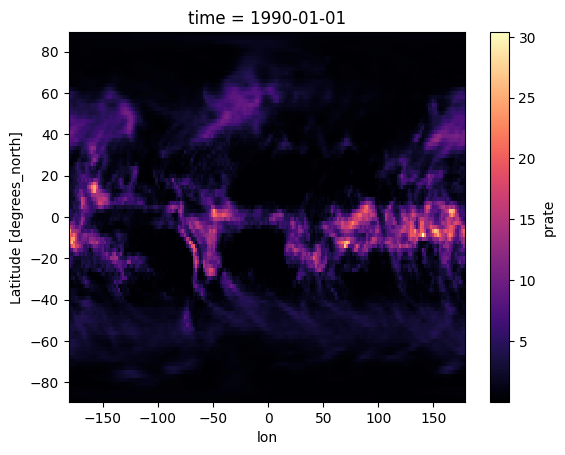

In [ ]:
## Plot the global map of precipitation for a certain date
plot_date = '1990-01'
plotme = precip['prate'].sel(time = plot_date)
plotme.plot(cmap = 'magma')

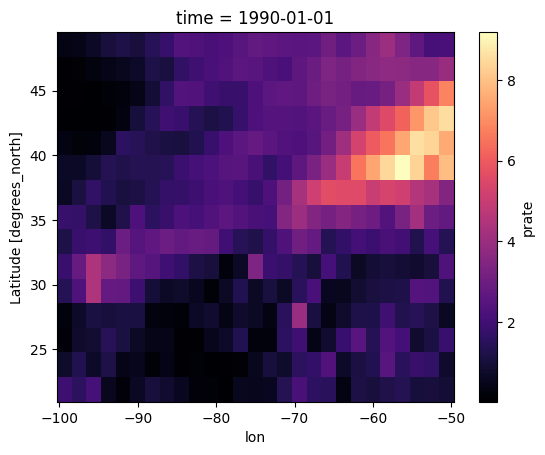

In [ ]:
## Zoom in on the map to plot a smaller segment
plotme = precip['prate'].sel(time = plot_date).sel(lat = slice(20,50), lon = slice(-100, -50))
plotme.plot(cmap = 'magma')

## Sample for landslide lat/lon

In [ ]:
print(os.getcwd())
landslide_data = pd.read_csv('/content/drive/MyDrive/Landslide_Detection/Global_Landslide_Catalog_updated.csv')
landslide_data

/content/drive/MyDrive/Landslide_Detection


,event_id,event_date,landslide_category,landslide_trigger,landslide_size,fatality_count,injury_count,country_name,longitude,latitude,precip_index,elevation,slope,aspect,soil moisture,vegetation_cover_ndvi,soil_type
0,35,03/12/2007 12:00:00 AM,landslide,rain,medium,2.0,NaN,India,74.9112,34.0935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,37,03/19/2007 12:00:00 AM,landslide,rain,medium,2.0,NaN,India,74.3333,33.8778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,43,03/23/2007 12:00:00 AM,landslide,downpour,medium,10.0,NaN,India,74.3313,33.9659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,57,04/11/2007 12:00:00 AM,landslide,downpour,medium,NaN,NaN,India,88.6193,27.4459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,73,05/08/2007 12:00:00 AM,landslide,rain,medium,NaN,NaN,India,75.2310,33.2420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260,9618,10/15/2016 12:00:00 AM,rock_fall,downpour,small,0.0,0.0,India,88.4486,26.9343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1261,9617,10/15/2016 12:00:00 AM,landslide,unknown,medium,0.0,0.0,India,88.2796,26.8880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1262,9620,10/15/2016 12:00:00 AM,landslide,downpour,medium,0.0,0.0,India,88.5292,27.1720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1263,9619,10/15/2016 12:00:00 AM,landslide,rain,medium,0.0,0.0,India,88.3664,27.1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sample_idx = 1
sample_lat = landslide_data.iloc[sample_idx]['latitude']
sample_lon = landslide_data.iloc[sample_idx]['longitude']
date_parsed = pd.to_datetime(landslide_data['event_date'].iloc[sample_idx])
# Keep only year and month
sample_date = date_parsed.strftime('%Y-%m')

print(sample_lat)
print(sample_lon)

33.8778
74.3333


In [ ]:
sample_precip = precip['prate'].sel(time = sample_date).sel(lat = sample_lat, lon = sample_lon, method = 'nearest').values
sample_precip[0] # rainfall for that landslide date and location, in units of mm


4.7433458268642426

In [ ]:
## Create precip column
landslide_data['precip'] = np.repeat(np.nan, landslide_data.shape[0])
landslide_data['precip'].iloc[sample_idx] = sample_precip

<ipython-input-32-80c3985dc539>:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  landslide_data['precip'].iloc[sample_idx] = sample_precip
<ipython-input-32-80c3985dc539>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [ ]:
landslide_data

,event_id,event_date,landslide_category,landslide_trigger,landslide_size,fatality_count,injury_count,country_name,longitude,latitude,precip_index,elevation,slope,aspect,soil moisture,vegetation_cover_ndvi,soil_type,precip
0,35,03/12/2007 12:00:00 AM,landslide,rain,medium,2.0,NaN,India,74.9112,34.0935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,37,03/19/2007 12:00:00 AM,landslide,rain,medium,2.0,NaN,India,74.3333,33.8778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.743346
2,43,03/23/2007 12:00:00 AM,landslide,downpour,medium,10.0,NaN,India,74.3313,33.9659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,57,04/11/2007 12:00:00 AM,landslide,downpour,medium,NaN,NaN,India,88.6193,27.4459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,73,05/08/2007 12:00:00 AM,landslide,rain,medium,NaN,NaN,India,75.2310,33.2420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260,9618,10/15/2016 12:00:00 AM,rock_fall,downpour,small,0.0,0.0,India,88.4486,26.9343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1261,9617,10/15/2016 12:00:00 AM,landslide,unknown,medium,0.0,0.0,India,88.2796,26.8880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1262,9620,10/15/2016 12:00:00 AM,landslide,downpour,medium,0.0,0.0,India,88.5292,27.1720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1263,9619,10/15/2016 12:00:00 AM,landslide,rain,medium,0.0,0.0,India,88.3664,27.1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##Lat, Lon and Date arrays



In [ ]:
#create an array with all latitude and longtitude values
lat_lon = landslide_data[['latitude', 'longitude']]
lat_lon

,latitude,longitude
0,34.0935,74.9112
1,33.8778,74.3333
2,33.9659,74.3313
3,27.4459,88.6193
4,33.2420,75.2310
...,...,...
1260,26.9343,88.4486
1261,26.8880,88.2796
1262,27.1720,88.5292
1263,27.1695,88.3664


In [ ]:
# prompt: write the code to loop through all latitude and lon values and store both in 2 different arrays

#create empty arrays to store latitude and longitude values
latitude_values = []
longitude_values = []

#loop through the lat_lon array
for index, row in lat_lon.iterrows():
  latitude_values.append(row['latitude'])
  longitude_values.append(row['longitude'])



In [ ]:
# prompt: 1d array consisting of all date values from the landslide_data csv file in year-month-date

#create empty arrays to store date values
date_values = []

#loop through the landslide_data DataFrame
for index, row in landslide_data.iterrows():
  try:
    # Convert the 'event_date' string to a datetime object
    date_parsed = pd.to_datetime(row['event_date'])
    # Format the date as 'YYYY-MM-DD'
    formatted_date = date_parsed.strftime('%Y-%m-%d')
    date_values.append(formatted_date)
  except ValueError:
    # Handle cases where the 'event_date' is not a valid date
    print(f"Invalid date format for index {index}: {row['event_date']}")
    date_values.append(None)  # Or another placeholder value

# Convert the list of date strings to a NumPy array
date_array = np.array(date_values)

date_array

array(['2007-03-12', '2007-03-19', '2007-03-23', ..., '2016-10-15',
       '2016-10-15', '2016-10-17'], dtype='<U10')

##Lat_long values with landslide=0

In [ ]:
existing_data = pd.read_csv('Global_Landslide_Catalog_updated.csv')
existing_latitudes = existing_data['latitude'].values
existing_longitudes = existing_data['longitude'].values

In [ ]:
import numpy as np

def generate_unique_random_value(existing_values, min_val, max_val, tolerance=1):
    while True:
        random_value = np.random.uniform(min_val, max_val)
        if np.all(np.abs(existing_values - random_value) > tolerance):
            return random_value

num_rows = 6000  # Adjust the number of rows as needed
latitude_0 = [generate_unique_random_value(existing_latitudes, -50, 50) for _ in range(num_rows)]
longitude_0 = [generate_unique_random_value(existing_longitudes, -170, 170) for _ in range(num_rows)]

In [ ]:
print(latitude_0)
print(longitude_0)

[-42.81878392844488, -21.344716469775882, -44.61342267634084, 43.97773620961158, -17.709582753891027, -47.93338286428646, 43.38694521327771, -43.20413478354854, -7.06695762639805, 41.417310256350305, -46.266739581583394, -13.257418603652361, 37.903016719276906, -21.467501151097412, -35.46314063789595, -41.55077718846546, -1.4313243288253332, -42.66130124132004, -41.82388908982952, -6.890861433834431, -42.619387439142706, -20.25537471255141, -7.34602019455437, -9.989963410141776, -13.993384745197481, -40.90998284993598, -3.970705924932652, -5.091463932017447, 39.08545127639263, -43.87889103127092, -36.272608309761445, 3.4863495541319196, -16.212034691376054, -27.113696661172494, 39.72134218882299, 36.235639252486976, -28.80374244036443, -10.608877524197155, 3.766790117883801, 4.407803034262535, -33.65233699482346, -10.696998735675024, 48.664110129424216, -39.41295416455913, -34.73571993507011, -39.10484004853238, 47.71476860321306, -40.36231684025425, -22.12203202460854, 40.250978462478

In [ ]:
data = {'latitude': latitude_0, 'longitude': longitude_0}
df = pd.DataFrame(data)
df.to_csv('random_coordinates_unique.csv', index=False)

## Elevation

In [ ]:
import xarray as xr
import cftime

In [ ]:
elev = xr.open_dataarray('./elev.0.25-deg.nc', decode_times=False)

# Alternatively, if cftime is available, install it and try decoding the times
#elev = xr.open_dataarray('./elev.0.25-deg.nc', decode_times=True)
# If the time units are still not recognized, you might need to specify the calendar:
#elev = xr.open_dataarray('./elev.0.25-deg.nc', decode_times=True, use_cftime=True)  # Try setting use_cftime=True

elev

<xarray.DataArray 'data' (time: 1, lat: 720, lon: 1440)> Size: 4MB
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 3kB 89.88 89.62 89.38 89.12 ... -89.38 -89.62 -89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * time     (time) float32 4B 0.0
Attributes:
    long_name:  meters, from 5-min data
    units:      meters, from 5-min data

In [ ]:
#elev = xr.open_dataarray('./elev.0.25-deg.nc')
#elev

In [ ]:
## Clean up the lat/lon coordinates
## Convert 0 to 360 longitude to -180 to 180
elev = elev.assign_coords(lon = (((elev.lon + 180) % 360) - 180))

## Sort lat and lon coordinates in increasing order
elev = elev.sortby(elev.lon)
elev = elev.sortby(elev.lat)
elev = elev.squeeze()
elev

<xarray.DataArray 'data' (lat: 720, lon: 1440)> Size: 4MB
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
    time     float32 4B 0.0
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    long_name:  meters, from 5-min data
    units:      meters, from 5-min data

In [ ]:
sample_elev = elev.sel(lat = sample_lat, lon = sample_lon, method = 'nearest').values
print(sample_elev) # elevation in meters

2643.0


In [ ]:
sample_elev = elev.sel(lat = -44.22757507, lon = 169.0740366, method = 'nearest').values
print(sample_elev) # elevation in meters

1352.0


In [ ]:
#extending to all values for elevation

#elev_values = []
#for i in range(len(latitude_0)):
#  elev_values.append(elev.sel(lat = latitude_0[i], lon = longitude_0[i], method = 'nearest').values)
#for i in range(len(elev_values)):
# print(elev_values[i])

In [ ]:
#print(latitude_0)
#print(longitude_0)

In [ ]:
#indices = []
#for i in range(len(elev_values)):
#  if elev_values[i]>0:
#    indices.append(i)
#print(indices)

In [ ]:
final_lat_lon = pd.read_csv('Global_Landslide_Catalog_Export - chosen_lat_lon (2).csv')
updated_lat = final_lat_lon['Latitude'].values
updated_lon = final_lat_lon['Longitude'].values

In [ ]:
updated_elev = []
#updated_lat = []
#updated_lon = []
#for i in range(len(indices)):
#  updated_elev.append(elev_values[indices[i]])
#  updated_lat.append(latitude_0[indices[i]])
#  updated_lon.append(longitude_0[indices[i]])
#print(len(updated_elev))

for i in range(len(updated_lat)):
  updated_elev.append(elev.sel(lat = updated_lat[i], lon = updated_lon[i], method = 'nearest').values)

for i in range(len(updated_lat)):
  print(updated_elev[i])

1352.0
2024.0
498.0
571.0
122.0
532.0
1416.0
205.0
251.0
130.0
1105.0
1283.0
1387.0
968.0
450.0
104.0
437.0
3881.0
587.0
285.0
201.0
1223.0
346.0
212.0
739.0
1495.0
385.0
237.0
1545.0
1066.0
240.0
198.0
692.0
475.0
401.0
1132.0
142.0
460.0
60.0
321.0
744.0
2404.0
807.0
60.0
172.0
3593.0
565.0
436.0
1104.0
1216.0
335.0
108.0
55.0
464.0
1110.0
45.0
1602.0
57.0
2382.0
164.0
101.0
966.0
1527.0
642.0
1193.0
294.0
696.0
1653.0
103.0
337.0
591.0
7.0
1355.0
130.0
98.0
996.0
890.0
1739.0
450.0
1231.0
284.0
90.0
281.0
184.0
869.0
144.0
150.0
401.0
62.0
209.0
982.0
1119.0
262.0
504.0
160.0
93.0
738.0
117.0
138.0
802.0
390.0
443.0
167.0
750.0
22.0
682.0
37.0
989.0
155.0
1023.0
103.0
379.0
297.0
1206.0
529.0
267.0
227.0
1379.0
545.0
219.0
968.0
148.0
128.0
422.0
401.0
90.0
1390.0
182.0
430.0
3915.0
247.0
315.0
96.0
2702.0
517.0
382.0
129.0
477.0
32.0
1218.0
319.0
344.0
1852.0
204.0
133.0
1250.0
878.0
1143.0
1981.0
23.0
486.0
336.0
267.0
1061.0
166.0
1530.0
382.0
90.0
523.0
110.0
461.0
271.0
4.0
496

In [ ]:
print(updated_lat)

[-44.22757507  40.91261957 -11.63807666 ...  -9.42740646  -0.77810698
   5.00182557]


In [ ]:
print(updated_elev[0])

1352.0


In [ ]:
# prompt: create a .csv file with 3 columns - elevation (updated_elev array), latitude (updated_lat array), longitude(updated_lon array)

# Create a DataFrame
data = {'elevation': updated_elev, 'latitude': updated_lat, 'longitude': updated_lon}
df = pd.DataFrame(data)

# Export to CSV
df.to_csv('elevation_data_00.csv', index=False)


##Slope
---



In [ ]:
import rioxarray

In [ ]:
def tif_to_xarray(tif_path):
  pf = rioxarray.open_rasterio(tif_path)
  pf = pf.drop_vars('band').squeeze()
  pf = pf.rename({'x':'lon', 'y': 'lat'})
  pf = pf.sortby(pf.lat)

  return pf


In [ ]:
slope_filepath = './slope_10KMmd_SRTM.tif'

slope = tif_to_xarray(slope_filepath)

sample_slope = slope.sel(lat = sample_lat, lon = sample_lon, method = 'nearest').values

print(sample_slope)

26.900928


In [ ]:
print(slope)

<xarray.DataArray (lat: 1440, lon: 4320)> Size: 25MB
[6220800 values with dtype=float32]
Coordinates:
  * lon          (lon) float64 35kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
  * lat          (lat) float64 12kB -59.96 -59.87 -59.79 ... 59.79 59.88 59.96
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_DOCUMENTNAME:      5 arc-minute median  slope
    TIFFTAG_IMAGEDESCRIPTION:  5 arc-minute slope  median  derived from SRTM4...
    TIFFTAG_SOFTWARE:          gdal 1.10.0 & pktools 2.6.4 & GRASS7
    TIFFTAG_DATETIME:          2016
    TIFFTAG_ARTIST:            Giuseppe Amatulli (giuseppe.amatulli@yale.edu ...
    AREA_OR_POINT:             Area
    _FillValue:                -9999.0
    scale_factor:              1.0
    add_offset:                0.0


In [ ]:
#For all other values
slope_values = []
for i in range(len(latitude_values)):
  slope_values.append(slope.sel(lat = latitude_values[i], lon = longitude_values[i], method = 'nearest').values)
for i in range(len(slope_values)):
  print(slope_values[i])


1.5348498
26.900928
25.634022
26.507221
22.315447
24.50966
0.6917442
0.7337011
1.8763878
0.7656122
0.8817776
4.4754424
0.79624486
0.58900684
5.145551
0.93445754
22.315447
25.282007
0.9903765
1.3123267
0.4891489
25.708572
7.480585
0.0
18.981455
19.983921
27.370796
29.18748
25.374279
22.419485
22.315447
6.3748455
2.8098881
3.5296936
3.351473
24.012833
1.3168739
0.45097467
21.80371
5.616322
12.726394
20.155613
5.2169256
23.096367
0.6377613
12.484962
5.720484
18.934153
23.096367
17.18032
24.62574
22.419485
1.7289196
18.671322
27.891369
14.955029
24.50966
21.670856
9.266632
24.62574
6.54958
0.9903765
25.960217
23.955828
0.9903765
14.565404
15.499401
14.955029
20.382748
15.256599
10.551854
1.0936639
33.49131
24.477018
24.323265
22.315447
31.118202
31.118202
1.4004644
12.826017
22.315447
32.67094
10.145185
0.93445754
22.65813
0.93445754
16.324905
3.9922423
16.793007
27.91993
1.1778892
0.5468818
18.263939
0.6653007
1.5656888
27.302584
19.507128
22.419485
10.551854
22.419485
21.80371
18.921211


In [ ]:
print(updated_lat)

[-44.22757507  40.91261957 -11.63807666 ...  -9.42740646  -0.77810698
   5.00182557]


In [ ]:
slope_df = pd.DataFrame(slope_values, columns=['Slope']) # Assuming 'Elevation' is a suitable column name

# 2. Export to CSV
slope_df.to_csv('slope_data.csv', index=False)  # index=False to exclude row indices

In [ ]:
#Slope for landslide=0

slope_values_0 = []
for i in range(len(updated_lat)):
  slope_values_0.append(slope.sel(lat = updated_lat[i], lon = updated_lon[i], method = 'nearest').values)
for i in range(len(slope_values_0)):
  print(slope_values_0[i])

28.595055
4.088581
2.523593
0.5468818
0.3943678
5.033905
8.139162
3.2486062
9.478758
0.3458847
0.3943678
4.8858414
9.21913
6.509965
0.5468818
1.0991174
3.6113625
2.643664
8.564847
0.24457891
10.499711
0.77338415
5.6909976
0.78869826
8.781887
20.558506
3.7535284
0.77338415
15.379808
1.8875029
0.58900684
0.5468818
2.885265
0.94083506
1.554196
0.5468818
1.4671617
1.6547548
1.0317743
0.8817776
1.8329121
20.735619
18.151377
0.3458847
4.400563
22.619106
4.3490047
3.1290429
1.5770978
0.4891489
3.7614427
1.4216441
0.83295214
5.9077168
0.94083506
0.43751022
5.263773
10.342392
10.940533
1.1259878
0.4891489
1.207959
0.93445754
0.9280362
8.657184
0.7003368
6.288404
2.643664
0.4891489
0.9018935
1.2227163
0.3943678
0.97822654
0.3458847
1.8099536
7.308912
7.7121067
2.8415399
2.9727786
10.77886
2.153515
1.7799994
2.5200415
2.3061209
2.2136676
0.83295214
1.6975324
5.0923657
0.3458847
1.4216441
0.43751022
9.302088
3.0616663
5.741082
4.4754424
0.32813546
1.4258422
0.3943678
1.6975324
3.9390395
2.1030152


In [ ]:
for i in range(len(slope_values_0)):
  print(slope_values_0[i])

28.595055
4.088581
2.523593
0.5468818
0.3943678
5.033905
8.139162
3.2486062
9.478758
0.3458847
0.3943678
4.8858414
9.21913
6.509965
0.5468818
1.0991174
3.6113625
2.643664
8.564847
0.24457891
10.499711
0.77338415
5.6909976
0.78869826
8.781887
20.558506
3.7535284
0.77338415
15.379808
1.8875029
0.58900684
0.5468818
2.885265
0.94083506
1.554196
0.5468818
1.4671617
1.6547548
1.0317743
0.8817776
1.8329121
20.735619
18.151377
0.3458847
4.400563
22.619106
4.3490047
3.1290429
1.5770978
0.4891489
3.7614427
1.4216441
0.83295214
5.9077168
0.94083506
0.43751022
5.263773
10.342392
10.940533
1.1259878
0.4891489
1.207959
0.93445754
0.9280362
8.657184
0.7003368
6.288404
2.643664
0.4891489
0.9018935
1.2227163
0.3943678
0.97822654
0.3458847
1.8099536
7.308912
7.7121067
2.8415399
2.9727786
10.77886
2.153515
1.7799994
2.5200415
2.3061209
2.2136676
0.83295214
1.6975324
5.0923657
0.3458847
1.4216441
0.43751022
9.302088
3.0616663
5.741082
4.4754424
0.32813546
1.4258422
0.3943678
1.6975324
3.9390395
2.1030152


In [ ]:
slope_df_0 = pd.DataFrame({'slope': slope_values_0, 'latitude': updated_lat, 'longitude': updated_lon}) # Assuming 'Elevation' is a suitable column name

# 2. Export to CSV
slope_df_0.to_csv('slope_data_0.csv', index=False)  # index=False to exclude row indices

##Precip Lag (2007-2016)

In [ ]:
from siphon.catalog import TDSCatalog
import ipywidgets as widgets

In [ ]:
catUrl = "http://psl.noaa.gov/thredds/catalog/Datasets/ncep.reanalysis2/Dailies/gaussian_grid/catalog.xml";
catalog = TDSCatalog(catUrl) #rather, download locally on laptop and then access
folder_name = 'Precipitation'

KeyboardInterrupt: 

In [ ]:
filepath = './prate.sfc.gauss.*.nc'
new_precip = xr.open_mfdataset(filepath, combine = 'by_coords') #new_precip is precip from 2007 to 2016
new_precip

<xarray.Dataset> Size: 290MB
Dimensions:    (time: 4018, nbnds: 2, lat: 94, lon: 192)
Coordinates:
  * lat        (lat) float32 376B 88.54 86.65 84.75 ... -84.75 -86.65 -88.54
  * lon        (lon) float32 768B 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time       (time) datetime64[ns] 32kB 2007-01-01 2007-01-02 ... 2017-12-31
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 64kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    prate      (time, lat, lon) float32 290MB dask.array<chunksize=(1, 94, 192), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.0
    title:          Daily NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2007/12 by Hoop\nConverted to chunked, deflated n...

In [ ]:
new_precip['prate']

In [ ]:
new_precip['prate'] = new_precip['prate']*86400

In [ ]:
dates = new_precip['prate'].coords['time'].values
dates

In [ ]:
new_precip = new_precip.assign_coords(lon = (((new_precip.lon + 180) % 360) - 180))

## Sort lat and lon coordinates in increasing order
new_precip = new_precip.sortby(new_precip.lon)
new_precip = new_precip.sortby(new_precip.lat)

In [ ]:
new_precip['prate'].sel(time = '2007-03-11').sel(lat = 34.0935, lon = 74.9112, method = 'nearest').values


In [ ]:
#Adding for a set date, lat, lon

precipitation_data = []

# Iterate through latitude, longitude, and date values
for i in range(len(latitude_values)):
  lag_days = 1
  date = pd.to_datetime(date_values[i]) - pd.Timedelta(days=6)
  sample_precip = new_precip['prate'].sel(time=date, lat=latitude_values[i], lon=longitude_values[i], method='nearest').values
  precipitation_data.append(sample_precip)

# Convert the list of precipitation data to a NumPy array
precipitation_array = np.array(precipitation_data)


In [ ]:
precipitation_array = pd.DataFrame(precipitation_array, columns=['precip_lag6'])
precipitation_array.to_csv('precip_lag6.csv', index=False)

In [ ]:
print(precipitation_array)

##Precip with landslide=0

In [ ]:
filepath_0 = './prate.sfc.gauss.2017.nc'
new_precip_0 = xr.open_mfdataset(filepath)

#verify if path exists
print(os.path.exists(filepath_0))

In [ ]:
new_precip_0['prate'] = new_precip_0['prate']*86400

In [ ]:
# prompt: code to find the size of new_precip_0

new_precip_0.sizes

In [ ]:
print(updated_lat)
print(updated_lon)

In [ ]:
precipitation_data_0 = []

# Set the specific date
specific_date = pd.to_datetime("2017-01-07")

# Iterate through latitude and longitude values
for i in range(len(updated_lat)):
        sample_precip = new_precip_0['prate'].sel(time=specific_date, lat=updated_lat[i], lon=updated_lon[i], method='nearest').values
        precipitation_data_0.append(sample_precip)

# Convert the list of precipitation data to a NumPy array
precipitation_array_0 = np.array(precipitation_data_0)

In [ ]:
precipitation_array = pd.DataFrame(precipitation_array_0, columns=['precip_lag06'])
precipitation_array.to_csv('precip_lag06.csv', index=False)

## Next do a for loop, going through all the rows (all the sample_idx from 0 to n_rows)

##Vegetation Cover (nvdi)

##Soil Type

#Training ML Models

In [ ]:
!pip install xgboost tensorflow

##Training RF

###Landsight Lightweight

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset (replace with the path to your dataset if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Assuming your CSV has a column named 'Landslide_Value' to distinguish between landslide occurrences:
# Separate data based on 'Landslide_Value' column
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]  # Rows where Landslide_Value is 1
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]  # Rows where Landslide_Value is 0

# Combine the separated data
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select relevant features: precip_lag0 to precip_lag6, elevation, slope, and landslide occurrence
features = ['precip_lag0',
            'precip_lag1',
            #'precip_lag2',
            #'precip_lag3',
            #'precip_lag4',
            #'precip_lag5',
            #'precip_lag6',
            'Elevation',
            'Slope']
target = 'Landslide_Value'

# Drop rows with missing values in relevant columns
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"Model Accuracy: {accuracy:.2f}")


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature importances from the trained model
importances = rf_model.feature_importances_
feature_names = X_train.columns


# Create a DataFrame to store feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Import the necessary library for F1 score
from sklearn.metrics import f1_score

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate the F1 score
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"Model Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
rf = RandomForestClassifier(random_state=42)

# Define the hyperparameters to search over
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.2f}")

# Use the best estimator to predict on test data
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")


In [ ]:
# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = cleaned_data[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


###Landsight complete

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset (replace with the path to your dataset if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Assuming your CSV has a column named 'Landslide_Value' to distinguish between landslide occurrences:
# Separate data based on 'Landslide_Value' column
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]  # Rows where Landslide_Value is 1
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]  # Rows where Landslide_Value is 0

# Combine the separated data
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select relevant features: precip_lag0 to precip_lag6, elevation, slope, and landslide occurrence
features = ['precip_lag0',
            'precip_lag1',
            'precip_lag2',
            'precip_lag3',
            'precip_lag4',
            'precip_lag5',
            'precip_lag6',
            'Elevation',
            'Slope']
target = 'Landslide_Value'

# Drop rows with missing values in relevant columns
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"Model Accuracy: {accuracy:.2f}")


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature importances from the trained model
importances = rf_model.feature_importances_
feature_names = X_train.columns


# Create a DataFrame to store feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Import the necessary library for F1 score
from sklearn.metrics import f1_score

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate the F1 score
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"Model Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")


In [ ]:
# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = cleaned_data[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

##LSTM

In [ ]:
1# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import f1_score

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precipitation lags (as sequential input), elevation, and slope
precip_features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3',
                   'precip_lag4', 'precip_lag5', 'precip_lag6']
static_features = ['Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[precip_features + static_features + [target]].dropna()

# Split data into features (X) and target (y)
X_precip = cleaned_data[precip_features].values  # Shape: (n_samples, 7)
X_static = cleaned_data[static_features].values  # Shape: (n_samples, 2)
y = cleaned_data[target].values  # Shape: (n_samples,)

# Standardize static features (optional but recommended)
scaler = StandardScaler()
X_static = scaler.fit_transform(X_static)

# Reshape precipitation data to fit LSTM input: (n_samples, timesteps, features)
X_precip = X_precip.reshape((X_precip.shape[0], X_precip.shape[1], 1))  # Shape: (n_samples, 7, 1)

# Split the data into 80% training and 20% testing
X_precip_train, X_precip_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_precip, X_static, y, test_size=0.2, random_state=42
)

# Build the LSTM model
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(7, 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))

# Combine static features by adding a Dense layer for them
model.add(Dense(32, activation='relu', input_dim=2))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit([X_precip_train, X_static_train], y_train,
                    epochs=20, batch_size=32,
                    validation_split=0.2, verbose=1)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate([X_precip_test, X_static_test], y_test, verbose=1)

# Print the accuracy
print(f"Test Accuracy: {test_accuracy:.2f}")

#Finding f1
# Make predictions on the test data
y_pred_proba = model.predict([X_precip_test, X_static_test])
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

# Calculate F1 score
f1 = f1_score(y_test, y_pred)

# Print the F1 score
print(f"F1 Score: {f1:.2f}")


##Logistic Regression

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3',
            'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features to improve the performance of the logistic regression model
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
logreg_model = LogisticRegression(random_state=42, max_iter=1000)
logreg_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = logreg_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"Logistic Regression Model Accuracy: {accuracy:.2f}")

# Make predictions on the test data
y_pred = logreg_model.predict(X_test)

# Calculate the F1 score
f1 = f1_score(y_test, y_pred)

# Print the F1 score
print(f"F1 Score: {f1:.2f}")


##XGBoost

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0',
            'precip_lag1',
            'precip_lag2',
            'precip_lag3',
            'precip_lag4',
            'precip_lag5',
            'precip_lag6',
            'Elevation',
            'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features to improve the performance of the model
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost classifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = xgb_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"XGBoost Model Accuracy: {accuracy:.2f}")

# Make predictions on the test data
y_pred = xgb_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate the F1 score
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"XGBoost Model F1 Score: {f1:.2f}")


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3',
            'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features using a DataFrame with column names
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost classifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = xgb_model.predict(X_test)

# Calculate the accuracy and F1 score of the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"XGBoost Model Accuracy: {accuracy:.2f}")
print(f"XGBoost Model F1 Score: {f1:.2f}")


##ANN

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3',
            'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features for better training performance
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))  # Input layer + first hidden layer
model.add(Dropout(0.2))  # Dropout for regularization
model.add(Dense(32, activation='relu'))  # Second hidden layer
model.add(Dropout(0.2))  # Dropout for regularization
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

# Make predictions on the test data
y_pred_prob = model.predict(X_test)  # Probability outputs
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"ANN Model Accuracy: {accuracy:.2f}")

# Make predictions on the test data
y_pred_prob = model.predict(X_test)  # Probability outputs
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate the F1 score
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"ANN Model F1 Score: {f1:.2f}")

##Training SVC

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3',
            'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features for better performance
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Kernelized SVC model with an RBF kernel
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svc_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print(f"SVC Model Accuracy: {accuracy:.2f}")

# Make predictions on the test data
y_pred = svc_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate the F1 score
f1 = f1_score(y_test, y_pred)

print(f"SVC Model F1 Score: {f1:.2f}")


##Training KNN

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3',
            'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features for better performance
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = knn_model.predict(X_test)

# Calculate the accuracy and F1 score of the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"KNN Model Accuracy: {accuracy:.2f}")
print(f"KNN Model F1 Score: {f1:.2f}")


##Deep Learning

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0', 'precip_lag1', 'precip_lag2',
            'precip_lag3', 'precip_lag4', 'precip_lag5',
            'precip_lag6', 'Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features to improve model performance
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the deep learning model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model with appropriate loss and optimizer
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50,
                    batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Deep Learning Model Accuracy: {test_accuracy:.2f}")

# Make predictions on the test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate the accuracy and F1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"Deep Learning Model Accuracy: {accuracy:.2f}")
print(f"Deep Learning Model F1 Score: {f1:.2f}")


##BPNN

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load the dataset (replace with your file path if necessary)
file_path = "Global_Landslide_Catalog_Export - updated.csv"
rf_data = pd.read_csv(file_path)

# Separate data based on 'Landslide_Value'
landslide_1 = rf_data[rf_data['Landslide_Value'] == 1]
landslide_0 = rf_data[rf_data['Landslide_Value'] == 0]

# Combine the data and select relevant features
combined_data = pd.concat([landslide_1, landslide_0], ignore_index=True)

# Select features: precip_lag0 to precip_lag6, elevation, and slope
features = ['precip_lag0', 'precip_lag1', 'precip_lag2',
            'precip_lag3', 'precip_lag4', 'precip_lag5',
            'precip_lag6', 'Elevation', 'Slope']
target = 'Landslide_Value'

# Drop rows with missing values
cleaned_data = combined_data[features + [target]].dropna()

# Split the data into features (X) and target (y)
X = cleaned_data[features]
y = cleaned_data[target]

# Standardize the features to improve model performance
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the BPNN model
bpnn_model = Sequential()

# Input layer + first hidden layer with 64 neurons, ReLU activation
bpnn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

# Second hidden layer with 32 neurons, ReLU activation
bpnn_model.add(Dense(32, activation='relu'))

# Output layer with sigmoid activation for binary classification
bpnn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
bpnn_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Train the model using backpropagation
history = bpnn_model.fit(X_train, y_train, epochs=50,
                         batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test data
test_loss, test_accuracy = bpnn_model.evaluate(X_test, y_test)
print(f"BPNN Model Accuracy: {test_accuracy:.2f}")

# Make predictions on the test data
y_pred_prob = bpnn_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate the accuracy and F1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the accuracy and F1 score
print(f"BPNN Model Accuracy: {accuracy:.2f}")
print(f"BPNN Model F1 Score: {f1:.2f}")


#Sampling for Year 2020

##Landslide lat_lon

In [ ]:
trial_data = pd.read_csv('2020_data - updated_clean.csv')
print(trial_data)
trial_lat = trial_data['latitude'].values
trial_lon = trial_data['longitude'].values

In [ ]:
print(trial_lat)
print(trial_lon)

##Elevation

In [ ]:
trial_elev = []

In [ ]:
sample_elev_2020 = (elev.sel(lat = 11.32081667, lon = 76.62537222, method = 'nearest').values)

In [ ]:
for i in range(len(trial_lat)):
  trial_elev.append(elev.sel(lat = trial_lat[i], lon = trial_lon[i], method = 'nearest').values)

In [ ]:
print(len(trial_elev))
print(len(trial_lat))
print(len(trial_lon))

In [ ]:
elev_2020 = {'elevation': trial_elev, 'latitude': trial_lat, 'longitude': trial_lon}
df = pd.DataFrame(elev_2020)

# Export to CSV
df.to_csv('trial_elev2020.csv', index=False)

##Slope

In [ ]:
slope_new_val = []
for i in range(len(trial_lat)):
  slope_new_val.append(slope.sel(lat = trial_lat[i], lon = trial_lon[i], method = 'nearest').values)
for i in range(len(slope_new_val)):
  print(slope_new_val[i])
print(len(slope_new_val))

In [ ]:
slope_df_2020 = pd.DataFrame({'slope': slope_new_val, 'latitude': trial_lat, 'longitude': trial_lon}) # Assuming 'Elevation' is a suitable column name

# 2. Export to CSV
slope_df_2020.to_csv('slope_data_2020.csv', index=False)  # index=False to exclude row indices

##Precip

#Using GraphCast

In [ ]:
!pip install zarr gcsfs cartopy

In [ ]:
import gcsfs
import zarr
import xarray as xr

In [ ]:
!pip install google-auth google-auth-oauthlib


In [ ]:
from google.colab import auth
auth.authenticate_user()


In [ ]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/path/to/your/service-account-file.json"


In [ ]:
gcast = xr.open_zarr('gs://weatherbench2/datasets/graphcast/2020/date_range_2019-11-16_2021-02-01_12_hours_derived.zarr')
gcast

In [ ]:
gcast['total_precipitation_24hr'].coords['time'].values

In [ ]:
gcast_precip = gcast['total_precipitation_24hr']

## Change longitude from 0 to 360 to -180 to 180
gcast_precip = gcast_precip.assign_coords(lon = (((gcast_precip.lon + 180) % 360) - 180))
gcast_precip = gcast_precip.sortby(gcast_precip.lon)

## Store hourly version of prediction_timestep for reference
hourly_format = gcast_precip.sel(time = '2020-06-15-00').coords['prediction_timedelta'].values.astype('timedelta64[h]') / np.timedelta64(1, 'h')

# convert from meters to mm
gcast_precip = gcast_precip * 1000

gcast_precip

In [ ]:
## Data is stored in 12 hour increments, so add '-00' to select midnight. '-12' would select noon.
gcast_precip.sel(time = '2020-06-15-00').coords['prediction_timedelta'].values#astype('timedelta64[h]')

In [ ]:
hourly_format

In [ ]:
## Now read in observed era5 data for the 'start date' data
era5 = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr')
era5_precip = era5['total_precipitation_24hr']
era5_precip = era5_precip.rename({'longitude':'lon', 'latitude': 'lat'})
era5_precip = era5_precip.assign_coords(lon = (((era5_precip.lon + 180) % 360) - 180))
era5_precip = era5_precip.sortby(era5_precip.lon)
era5_precip = era5_precip.sortby(era5_precip.lat)

# convert from meters to mm
era5_precip = era5_precip * 1000


In [ ]:
start_date = '2020-08-06-00'  ## This would be 7 days before the landslide event date

precip_today = era5_precip.sel(time = start_date)  ## Equivalent to precip_lag6

## Extract the forecast for 24hr ahead; equivalent to precip_lag5
hour_forecast = 24
prediction_timedelta_idx = np.where(hourly_format == hour_forecast)[0][0]
forecast_1day = gcast_precip.sel(time = start_date).isel(prediction_timedelta = prediction_timedelta_idx)
forecast_1day = forecast_1day.where(forecast_1day >=0, 0) # Set NAs to 0

# ## Extract the forecast for 48hr ahead; equivalent to precip_lag4
hour_forecast = 48
prediction_timedelta_idx = np.where(hourly_format == hour_forecast)[0][0]
forecast_2day = gcast_precip.sel(time = start_date).isel(prediction_timedelta = prediction_timedelta_idx)
forecast_2day = forecast_2day.where(forecast_2day >=0, 0) # Set NAs to 0

#..... continue until you have the full 7 days of precip needed for inputs

# ## Extract the forecast for 72hr ahead; equivalent to precip_lag3
hour_forecast = 72
prediction_timedelta_idx = np.where(hourly_format == hour_forecast)[0][0]
forecast_3day = gcast_precip.sel(time = start_date).isel(prediction_timedelta = prediction_timedelta_idx)
forecast_3day = forecast_3day.where(forecast_3day >=0, 0) # Set NAs to 0

# ## Extract the forecast for 96hr ahead; equivalent to precip_lag2
hour_forecast = 96
prediction_timedelta_idx = np.where(hourly_format == hour_forecast)[0][0]
forecast_4day = gcast_precip.sel(time = start_date).isel(prediction_timedelta = prediction_timedelta_idx)
forecast_4day = forecast_4day.where(forecast_4day >=0, 0) # Set NAs to 0

# ## Extract the forecast for 120hr ahead; equivalent to precip_lag1
hour_forecast = 120
prediction_timedelta_idx = np.where(hourly_format == hour_forecast)[0][0]
forecast_5day = gcast_precip.sel(time = start_date).isel(prediction_timedelta = prediction_timedelta_idx)
forecast_5day = forecast_5day.where(forecast_5day >=0, 0) # Set NAs to 0

# ## Extract the forecast for 144hr ahead; equivalent to precip_lag0 - day of landslide
hour_forecast = 144
prediction_timedelta_idx = np.where(hourly_format == hour_forecast)[0][0]
forecast_6day = gcast_precip.sel(time = start_date).isel(prediction_timedelta = prediction_timedelta_idx)
forecast_6day = forecast_6day.where(forecast_6day >=0, 0) # Set NAs to 0



#####################
# # Plot the data
# vmax = 100 # precip legend max in mm
# plt.figure(figsize = (15,5))
# plt.subplot(1,3,1)
# precip_today.plot(vmax = vmax)
# plt.title('Observed precip on ' + start_date)

# plt.subplot(1,3,2)
# forecast_1day.plot(vmax = vmax)
# plt.title('Forecast precip 1 day after ' + start_date)

# plt.subplot(1,3,3)
# forecast_2day.plot(vmax = vmax)
# plt.title('Forecast precip 2 days after ' + start_date)

In [ ]:
# prompt: generate precipitation (precip_lag6 to precip_lag0) values for a specific latitude, longitude from the code above and create a .csv file from it

import pandas as pd

# Assuming you have the necessary variables (precip_today, forecast_1day, etc.)
# from the previous code and the latitude/longitude you want to extract data for.
# Replace these with your actual values.

latitude = 25.62
longitude = 91.88272222

precip_lag6 = era5_precip.sel(time = start_date, lat=latitude, lon=longitude, method='nearest').values
precip_lag5 = forecast_1day.sel(lat=latitude, lon=longitude, method='nearest').values
precip_lag4 = forecast_2day.sel(lat=latitude, lon=longitude, method='nearest').values
precip_lag3 = forecast_3day.sel(lat=latitude, lon=longitude, method='nearest').values
precip_lag2 = forecast_4day.sel(lat=latitude, lon=longitude, method='nearest').values
precip_lag1 = forecast_5day.sel(lat=latitude, lon=longitude, method='nearest').values
precip_lag0 = forecast_6day.sel(lat=latitude, lon=longitude, method='nearest').values


# Create a dictionary to store the precipitation values
data = {
    'precip_lag6': [precip_lag6],
    'precip_lag5': [precip_lag5],
    'precip_lag4': [precip_lag4],
    'precip_lag3': [precip_lag3],
    'precip_lag2': [precip_lag2],
    'precip_lag1': [precip_lag1],
    'precip_lag0': [precip_lag0],
    'latitude': [latitude],
    'longitude': [longitude]
}

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Export the DataFrame to a CSV file
df.to_csv('precipitation_data_2020_7.csv', index=False)

In [ ]:
## Optional: Same plot but with coastlines
import cartopy.crs as ccrs

vmax = 100 # precip legend max in mm
plt.figure(figsize = (6,5))
ax = plt.axes(projection=ccrs.PlateCarree())  # Use PlateCarree for global data
precip_today.plot(ax=ax, transform=ccrs.PlateCarree(), vmax = vmax)
plt.title('Observed precip on ' + start_date)
ax.coastlines()  # Overlay coastlines
plt.show()

#Testing if Models are working

##2020 Data

Loading the 2020 data for testing

In [ ]:
testing_data = pd.read_csv('2020_data - updated_clean.csv')
print(testing_data)

##Testing XGBoost

In [ ]:
# prompt: in the 'testing_data' dataset, there are 27 rows where landslide=1, and the parameters are given (precip_lag0 to precip_lag6, elevation, slope). Using the XGBoost model created earlier, I want a total of the number of instances where the XGBoost model predicts the landslide

# Assuming 'xgb_model' and 'scaler' are defined from the previous code.
# Also assuming 'testing_data' DataFrame is loaded.

# Prepare the testing data
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
testing_data_subset = testing_data[features].dropna()  # Drop rows with missing values in features


# Scale the testing data using the same scaler used for training
scaled_testing_data = scaler.transform(testing_data_subset)


# Make predictions using the trained XGBoost model
landslide_predictions = xgb_model.predict(scaled_testing_data)

# Calculate the total number of instances predicted as landslide
total_predicted_landslides = np.sum(landslide_predictions)

print(f"Total predicted landslides in the testing data: {total_predicted_landslides}")

##Testing RF

In [ ]:
# prompt: in the 'testing_data' dataset, there are 27 rows where landslide=1, and the parameters are given (precip_lag0 to precip_lag6, elevation, slope). Using the RF model created earlier, I want a total of the number of instances where the RF model predicts the landslide

# Assuming 'rf_model' and 'scaler' are defined from the previous code.
# Also assuming 'testing_data' DataFrame is loaded.

# Prepare the testing data
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
testing_data_subset = testing_data[features].dropna()  # Drop rows with missing values in features

# Scale the testing data using the same scaler used for training
scaled_testing_data = scaler.transform(testing_data_subset)

# Assuming rf_model is your trained RandomForestClassifier
landslide_predictions = rf_model.predict(scaled_testing_data)

# Calculate the total number of instances predicted as landslide
total_predicted_landslides = np.sum(landslide_predictions)

print(f"Total predicted landslides in the testing data: {total_predicted_landslides}")

##Logistic Regression

In [ ]:
# prompt: in the 'testing_data' dataset, there are 27 rows where landslide=1, and the parameters are given (precip_lag0 to precip_lag6, elevation, slope). Using the Logistic Regression model created earlier, I want a total of the number of instances where the Logistic Regression model predicts the landslide

# Assuming 'model' and 'scaler' are defined from the previous code (Logistic Regression).
# Also assuming 'testing_data' DataFrame is loaded.

# Prepare the testing data
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
testing_data_subset = testing_data[features].dropna()  # Drop rows with missing values in features

# Scale the testing data using the same scaler used for training
scaled_testing_data = scaler.transform(testing_data_subset)

# Initialize and train the Logistic Regression model
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)

# Make predictions using the trained Logistic Regression model
landslide_predictions = logreg_model.predict(scaled_testing_data)

# Calculate the total number of instances predicted as landslide
total_predicted_landslides = np.sum(landslide_predictions)

print(f"Total predicted landslides in the testing data: {total_predicted_landslides}")

##KNN

In [ ]:
# prompt: in the 'testing_data' dataset, there are 27 rows where landslide=1, and the parameters are given (precip_lag0 to precip_lag6, elevation, slope). Using the KNN model created earlier, I want a total of the number of instances where the KNN model predicts the landslide

# Assuming 'knn_model' and 'scaler' are defined from the previous code.
# Also assuming 'testing_data' DataFrame is loaded.

# Prepare the testing data
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
testing_data_subset = testing_data[features].dropna()  # Drop rows with missing values in features

# Scale the testing data using the same scaler used for training
scaled_testing_data = scaler.transform(testing_data_subset)

# Make predictions using the trained KNN model
landslide_predictions = knn_model.predict(scaled_testing_data)

# Calculate the total number of instances predicted as landslide
total_predicted_landslides = np.sum(landslide_predictions)

print(f"Total predicted landslides in the testing data: {total_predicted_landslides}")

# Find the instances where the actual landslide value is 1
actual_landslides = testing_data[testing_data['Landslide_Value'] == 1]
print(f"Number of actual landslides in testing data: {len(actual_landslides)}")

##SVC

In [ ]:
# prompt: in the 'testing_data' dataset, there are 27 rows where landslide=1, and the parameters are given (precip_lag0 to precip_lag6, elevation, slope). Using the SVC model created earlier, I want a total of the number of instances where the SVC model predicts the landslide

# Prepare the testing data
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
testing_data_subset = testing_data[features].dropna()

# Scale the testing data
scaled_testing_data = scaler.transform(testing_data_subset)

# Predict using the SVC model
landslide_predictions = svc_model.predict(scaled_testing_data)

# Count predicted landslides
total_predicted_landslides = np.sum(landslide_predictions)
print(f"Total predicted landslides in the testing data using SVC: {total_predicted_landslides}")

##ANN

In [ ]:
# prompt: in the 'testing_data' dataset, there are 27 rows where landslide=1, and the parameters are given (precip_lag0 to precip_lag6, elevation, slope). Using the ANN model created earlier, I want a total of the number of instances where the ANN model predicts the landslide

# Assuming 'svc_model' and 'scaler' are defined from the previous code.
# Also assuming 'testing_data' DataFrame is loaded.

# Prepare the testing data
features = ['precip_lag0', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4', 'precip_lag5', 'precip_lag6', 'Elevation', 'Slope']
testing_data_subset = testing_data[features].dropna()

# Scale the testing data
scaled_testing_data = scaler.transform(testing_data_subset)

# Predict using the SVC model
landslide_predictions = svc_model.predict(scaled_testing_data)

# Count predicted landslides where the actual landslide is 1
actual_landslide_indices = testing_data[testing_data['Landslide_Value'] == 1].index
predicted_landslides_count = np.sum(landslide_predictions[testing_data_subset.index.isin(actual_landslide_indices)])


print(f"Total predicted landslides where actual landslide = 1 in the testing data using SVC: {predicted_landslides_count}")

#Creating a Global Susceptibility Map

In [ ]:
# prompt: Create a terrain susceptibility world map forecasting the prediction of landslide occurrence using the XGBoost Model; Elevation is stored in elev (Elevation); precipitation forecasts are stored in precip_today (precip_lag0), forecast_1day (precip_lag1), forecast_2day (precip_lag2) upto forecast_6day (precip_lag6); slope data in slope (Slope), although latitude of slope is limited from -59.96 to 59.96, so only do the map for latitudes between -59.96 to 59.96 and longitudes between -180 to 180; places; places where probability <0.1 is colored white, places with probability>0.1 is colored black


import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Define latitude and longitude ranges
min_lat, max_lat = 8.00, 38.00
min_lon, max_lon = 68.00, 98.00

# Create latitude and longitude arrays for the map
lats = np.arange(min_lat, max_lat, 0.5)  # Adjust resolution as needed (0.5 degree)
lons = np.arange(min_lon, max_lon, 0.5)

# Initialize arrays to store prediction probabilities
probabilities = np.empty((len(lats), len(lons)))

# Iterate through latitude and longitude pairs to make predictions
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        try:
            # Extract elevation and slope
            elevation = elev.sel(lat=lat, lon=lon, method='nearest').values
            slope_val = slope.sel(lat=lat, lon=lon, method='nearest').values

            # Assuming you have functions to extract precipitation forecasts for a given lat/lon.
            precip_lag6 = precip_today.sel(lat=lat, lon=lon, method='nearest').values
            precip_lag5 = forecast_1day.sel(lat=lat, lon=lon, method='nearest').values
            precip_lag4 = forecast_2day.sel(lat=lat, lon=lon, method='nearest').values
            precip_lag3 = forecast_3day.sel(lat=lat, lon=lon, method='nearest').values
            precip_lag2 = forecast_4day.sel(lat=lat, lon=lon, method='nearest').values
            precip_lag1 = forecast_5day.sel(lat=lat, lon=lon, method='nearest').values
            precip_lag0 = forecast_6day.sel(lat=lat, lon=lon, method='nearest').values

            # Combine features into a DataFrame to retain feature names
            features_arr = pd.DataFrame([[precip_lag0, precip_lag1, precip_lag2, precip_lag3, precip_lag4,
                                          precip_lag5, precip_lag6, elevation, slope_val]],
                                        columns=features)

            # Scale the input data
            scaled_features = scaler.transform(features_arr)

            # Make a prediction using the XGBoost model
            prediction_prob = xgb_model.predict_proba(scaled_features)[0, 1]
            probabilities[i, j] = prediction_prob

        except Exception as e:
            print(f"Error at lat={lat}, lon={lon}: {e}")
            probabilities[i, j] = np.nan  # Handle missing data or errors gracefully

# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
im = ax.pcolormesh(lons, lats, probabilities, cmap='viridis', transform=ccrs.PlateCarree(), vmin=0, vmax=1)
ax.coastlines()
plt.colorbar(im, label='Landslide Probability')  # Add a colorbar
plt.title('Global Landslide Susceptibility Map (XGBoost)')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

# Set up the figure and map projection
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the susceptibility map using lons, lats, and probabilities
im = ax.pcolormesh(lons, lats, probabilities,
                   transform=ccrs.PlateCarree(), cmap='viridis')

# Add coastlines and a colorbar
ax.coastlines()
plt.colorbar(im, label='Landslide Susceptibility')
plt.title('Global Landslide Susceptibility Map (XGBoost) with High Probability Markers')

# Find locations with a high probability threshold (e.g., > 0.997)
high_prob_locations = np.where(probabilities > 0.997)
high_prob_lats = lats[high_prob_locations[0]]  # Extract corresponding latitudes
high_prob_lons = lons[high_prob_locations[1]]  # Extract corresponding longitudes

# Plot black stars at high-probability locations
plt.scatter(high_prob_lons, high_prob_lats,
            color='black', s=50, marker='*',  # 's' controls size, 'marker' is set to '*'
            transform=ccrs.PlateCarree())

# Display the plot
plt.show()
